# Iris Flower Classification

## Objective

The objective of this project is to build machine learning classification models
that can identify the species of an iris flower based on its physical measurements.

The three target species are:
- Setosa
- Versicolor
- Virginica

## Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Jupyter Notebook

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [2]:
iris = load_iris()
print("Dataset loaded successfully!")

Dataset loaded successfully!


In [3]:
print("Feature names:")
print(iris.feature_names)
print("\nTarget names:")
print(iris.target_names)

Feature names:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Target names:
['setosa' 'versicolor' 'virginica']


In [4]:
df = pd.DataFrame(iris.data,columns=iris.feature_names)
df["species"] = iris.target
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [5]:
df["species"] = df["species"].map({0: "Setosa",1: "Versicolor",2: "Virginica"})
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


In [6]:
print("Dataset shape:", df.shape)

Dataset shape: (150, 5)


In [7]:
print(df.dtypes)

sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species                  str
dtype: object


In [8]:
print(df.isnull().sum())

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64


In [9]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [10]:
df.describe().round(2)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20
std,0.83,0.44,1.77,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


In [11]:
print(df["species"].value_counts())

species
Setosa        50
Versicolor    50
Virginica     50
Name: count, dtype: int64


## EDA Summary

- The dataset contains 150 observations and 5 columns.
- There are four numerical features and one target variable.
- The four features are sepal length, sepal width, petal length, and petal width.
- There are three iris species: Setosa, Versicolor, and Virginica.
- No missing values are present in the dataset.
- Each species contains 50 observations, so the dataset is balanced.

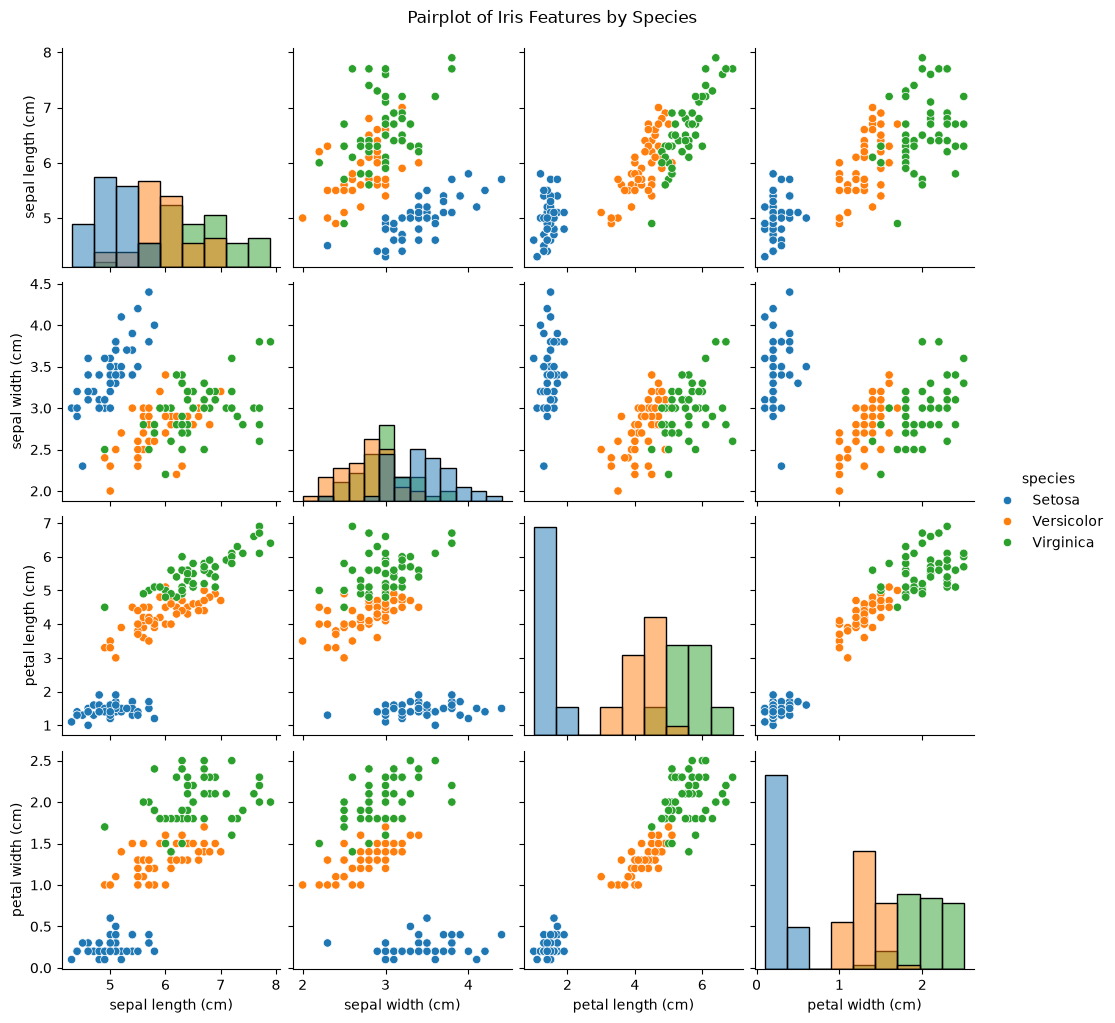

In [12]:
sns.pairplot( df,hue="species",diag_kind="hist")
plt.suptitle("Pairplot of Iris Features by Species", y=1.02)
plt.show()

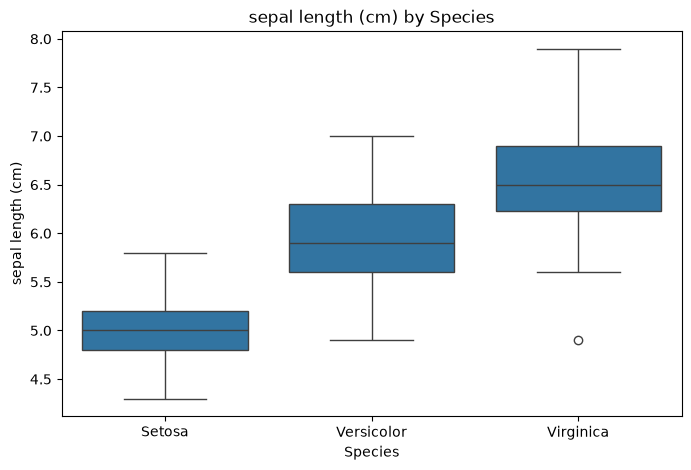

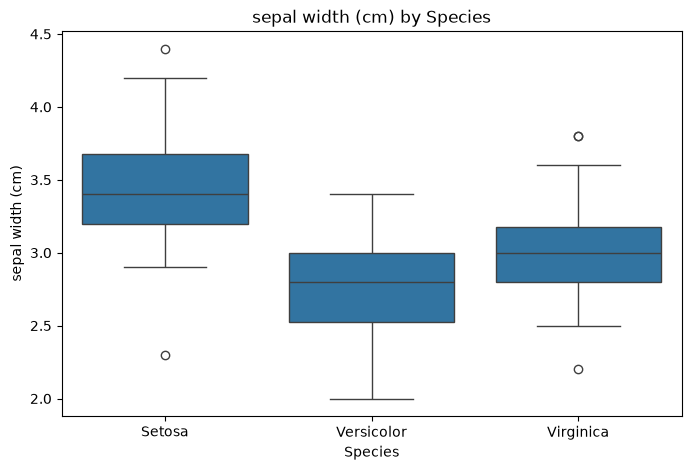

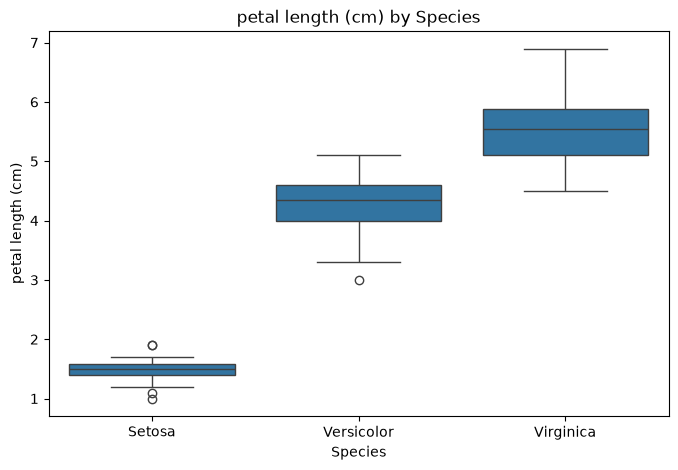

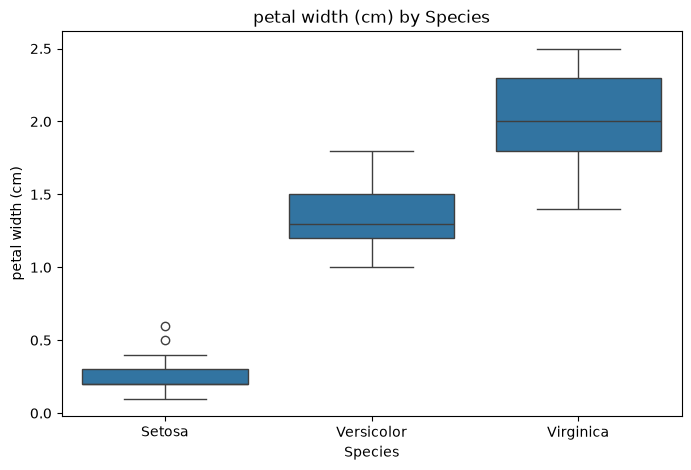

In [13]:
features = [
    "sepal length (cm)",
    "sepal width (cm)",
    "petal length (cm)",
    "petal width (cm)"
]

for feature in features:
    plt.figure(figsize=(8, 5))
    
    sns.boxplot(
        data=df,
        x="species",
        y=feature
    )
    
    plt.title(f"{feature} by Species")
    plt.xlabel("Species")
    plt.ylabel(feature)
    plt.show()

## Feature Selection Discussion

Based on the pairplot and box plots, petal length and petal width appear to be
the most discriminative features.

Setosa is clearly separated from Versicolor and Virginica based on petal
measurements. Versicolor and Virginica have some overlap, but petal length
and petal width still provide strong separation.

Sepal length and sepal width are useful features, but they show more overlap
between the different species.

Therefore, petal length and petal width appear to be the most important
features for distinguishing the iris species.

In [14]:
X = iris.data
y = iris.target
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (150, 4)
y shape: (150,)


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 120
Testing samples: 30


In [16]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Model 1 — Logistic Regression

Logistic Regression is a classification algorithm that predicts the probability
of an observation belonging to different classes.

In [17]:
logistic_model = LogisticRegression(
    max_iter=200
)

logistic_model.fit(
    X_train_scaled,
    y_train
)

y_pred_logistic = logistic_model.predict(X_test_scaled)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


In [18]:
logistic_accuracy = accuracy_score(
    y_test,
    y_pred_logistic
)

print("Logistic Regression Accuracy:",
      logistic_accuracy)

Logistic Regression Accuracy: 0.9333333333333333


In [19]:
print("Logistic Regression Classification Report:\n")

print(
    classification_report(
        y_test,
        y_pred_logistic,
        target_names=iris.target_names
    )
)

Logistic Regression Classification Report:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



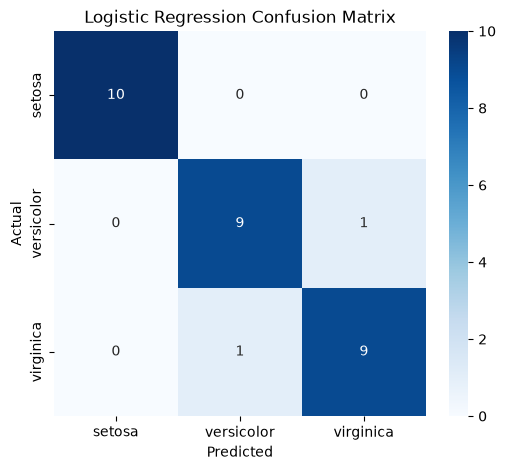

In [20]:
cm_logistic = confusion_matrix(
    y_test,
    y_pred_logistic
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_logistic,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")

plt.show()

## Model 2 — K-Nearest Neighbours

K-Nearest Neighbours classifies a new observation based on the classes of its
nearest neighbouring observations.

In [21]:
knn_model = KNeighborsClassifier(
    n_neighbors=5
)

knn_model.fit(
    X_train_scaled,
    y_train
)

y_pred_knn = knn_model.predict(X_test_scaled)

print("KNN model trained successfully!")

KNN model trained successfully!


In [22]:
knn_accuracy = accuracy_score(
    y_test,
    y_pred_knn
)

print("KNN Accuracy:", knn_accuracy)

KNN Accuracy: 0.9333333333333333


In [23]:
print("KNN Classification Report:\n")

print(
    classification_report(
        y_test,
        y_pred_knn,
        target_names=iris.target_names
    )
)

KNN Classification Report:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



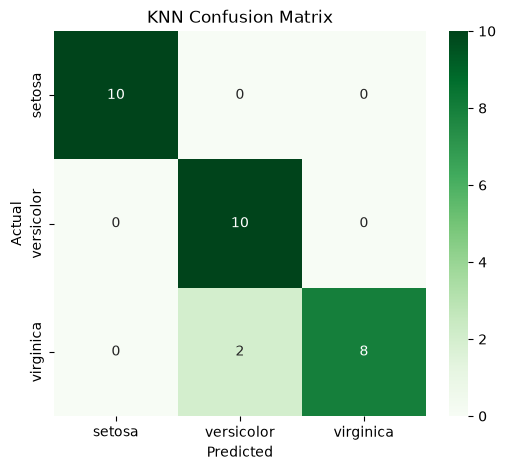

In [24]:
cm_knn = confusion_matrix(
    y_test,
    y_pred_knn
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_knn,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN Confusion Matrix")

plt.show()

In [25]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "K-Nearest Neighbours"
    ],
    "Accuracy": [
        logistic_accuracy,
        knn_accuracy
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.933333
1,K-Nearest Neighbours,0.933333


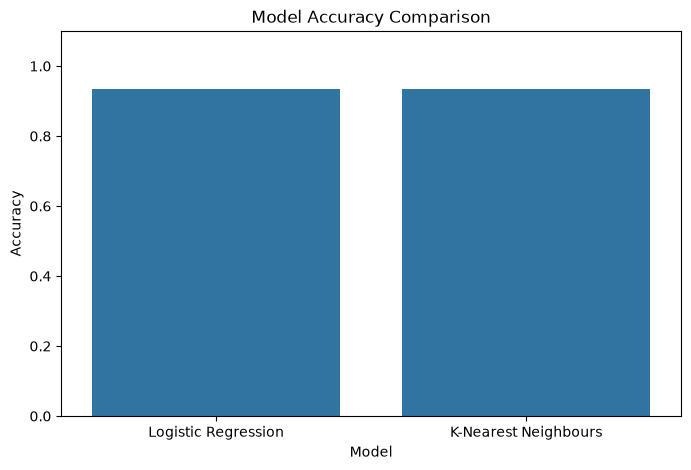

In [26]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=results,
    x="Model",
    y="Accuracy"
)

plt.ylim(0, 1.1)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Model")

plt.show()

In [27]:
best_model = results.loc[
    results["Accuracy"].idxmax()
]

print("Best Performing Model:",
      best_model["Model"])

print("Best Accuracy:",
      best_model["Accuracy"])

Best Performing Model: Logistic Regression
Best Accuracy: 0.9333333333333333


# Conclusion

In this project, machine learning models were developed to classify iris flowers
into three species: Setosa, Versicolor, and Virginica.

The Iris dataset was loaded directly from scikit-learn and exploratory data
analysis was performed to understand the dataset. The dataset contains 150
samples, four numerical features, and three target classes. No missing values
were found.

Pairplot and box plot visualizations showed that petal length and petal width
are the most discriminative features for distinguishing the iris species.

Two classification algorithms were trained and evaluated:

1. Logistic Regression
2. K-Nearest Neighbours

Both models were evaluated using accuracy, confusion matrices, precision,
recall, and F1-score.

The model with the highest test accuracy was selected as the best-performing
model. The results demonstrate that the Iris dataset is well suited for
classification because the species can be effectively separated using their
physical measurements.

1. Title
   ↓
2. Objective
   ↓
3. Technologies Used
   ↓
4. Import Libraries
   ↓
5. Load Dataset
   ↓
6. Dataset Overview
   ↓
7. Exploratory Data Analysis
      ├── Shape
      ├── Data Types
      ├── Null Values
      ├── Descriptive Statistics
      └── Class Distribution
   ↓
8. Data Visualization
      ├── Pairplot
      └── Boxplots
   ↓
9. Feature Selection Discussion
   ↓
10. Train/Test Split
   ↓
11. Feature Scaling
   ↓
12. Logistic Regression
      ├── Training
      ├── Accuracy
      ├── Classification Report
      └── Confusion Matrix
   ↓
13. KNN
      ├── Training
      ├── Accuracy
      ├── Classification Report
      └── Confusion Matrix
   ↓
14. Model Comparison
   ↓
15. Best Model
   ↓
16. Conclusion